In [1]:
import torch 
import torch.nn as nn # https://docs.pytorch.org/tutorials/beginner/nn_tutorial.html
import torch.optim as optim # https://docs.pytorch.org/tutorials/beginner/examples_nn/polynomial_optim.html
from torch.utils.data import DataLoader # https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
from torchvision import datasets, transforms # https://docs.pytorch.org/tutorials/beginner/basics/transforms_tutorial.html


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('restaurantmenuchanges.csv', escapechar='\\')
print(f"df's shape: {df.shape}, columns: {df.columns}")
df.head(1)

df's shape: (5000, 19), columns: Index(['createdOn', 'changeOperation', 'market', 'city', 'menuItemName',
       'menuItemDescription', 'menuItemCurrentPrice', 'menuItemPreviousPrice',
       'menuItemImageUrl', 'menuItemCategory', 'menuItemAverageRating',
       'menuItemRatingCount', 'restaurantName', 'restaurantDescription',
       'restaurantAddress', 'restaurantImageUrl', 'restaurantPriceRange',
       'restaurantLatitude', 'restaurantLongitude'],
      dtype='str')


,createdOn,changeOperation,market,city,menuItemName,menuItemDescription,menuItemCurrentPrice,menuItemPreviousPrice,menuItemImageUrl,menuItemCategory,menuItemAverageRating,menuItemRatingCount,restaurantName,restaurantDescription,restaurantAddress,restaurantImageUrl,restaurantPriceRange,restaurantLatitude,restaurantLongitude
0,2022-10-27 23:07:19.0000000,Create,"Houston, TX",Houston,1% Low Fat Milk (110 Cals),"As delicious as our sandwiches are, they are e...",$2.19,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Drinks,4.574205,566,Subway,"Sandwiches, Salads, Dessert, Snacks","2003 Pease St, Houston, TX 77003, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$,29.746686,-95.359915


In [3]:
# Keep only rows that have a menu item image URL and a current price,
# since both are required to train a CNN that predicts price from images.
image_col = 'menuItemImageUrl'
price_col = 'menuItemCurrentPrice'

df_clean = df.dropna(subset=[image_col, price_col]).copy()
df_clean = df_clean[df_clean[image_col].str.strip().astype(bool)]

df_clean[price_col] = (
    df_clean[price_col]
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

# Dedupe by image URL so the same picture can't appear in more than one split.
# The same item can appear many times in the changelog at different prices, so
# we take the MEDIAN price per URL (robust to outliers like promo $0 entries).
df_clean = (
    df_clean.groupby(image_col, as_index=False)
    .agg({price_col: 'median', **{c: 'first' for c in df_clean.columns if c not in (image_col, price_col)}})
    .reset_index(drop=True)
)

# Drop any accidental non-positive prices (free items / data glitches) and
# absurdly expensive outliers that would dominate regression loss.
df_clean = df_clean[(df_clean[price_col] > 0) & (df_clean[price_col] < 150)].reset_index(drop=True)

print(f"Original shape:        {df.shape}")
print(f"After NaN/price clean: {df.dropna(subset=[image_col, price_col]).shape}")
print(f"After URL dedupe:      {df_clean.shape}")
df_clean.head(3)

Original shape:        (5000, 19)
After NaN/price clean: (2739, 19)
After URL dedupe:      (2036, 19)


,createdOn,changeOperation,market,city,menuItemName,menuItemDescription,menuItemCurrentPrice,menuItemPreviousPrice,menuItemImageUrl,menuItemCategory,menuItemAverageRating,menuItemRatingCount,restaurantName,restaurantDescription,restaurantAddress,restaurantImageUrl,restaurantPriceRange,restaurantLatitude,restaurantLongitude
0,2022-10-27 23:13:04.0000000,Create,"Houston, TX",Houston,Jalapeno Biscuit,NaN,0.49,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Breads,4.195492,2440,Luby's,"Comfort Food, Burgers, American, Pickup, Chick...","1727 Old Spanish Trail, Houston, TX 77054, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$$,29.695966,-95.402326
1,2022-11-07 21:19:33.0000000,Create,"Houston, TX",Houston,Jus Single Side,NaN,0.49,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Dressings And Sauces,4.650694,3026,Cafe Express,"Lunch, Sandwiches, Modern European, Healthy, S...","1422 W Gray St, Houston, TX 77019, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$,29.753479,-95.399606
2,2022-10-27 23:23:53.0000000,Create,"Houston, TX",Houston,Spicy Cheese Sauce,Amigos Spicy Cheese Sauce made from scratch.,0.50,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Sauces & Salsas,0.000000,0,Zelda's Teriyaki,"Teriyaki, Chicken, Gluten-Free, Dessert","2616 Blodgett St, Houston, TX 77004, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$$,29.722689,-95.370483


In [4]:
import hashlib
import io
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import requests
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm

IMAGE_DIR = Path('images')
IMAGE_DIR.mkdir(exist_ok=True)

def url_to_path(url: str) -> Path:
    # Stable filename per URL so we never re-download the same image.
    name = hashlib.md5(url.encode('utf-8')).hexdigest() + '.jpg'
    return IMAGE_DIR / name

def download_one(url: str, timeout: float = 10.0) -> tuple[str, Path | None]:
    path = url_to_path(url)
    if path.exists() and path.stat().st_size > 0:
        return url, path
    try:
        resp = requests.get(url, timeout=timeout)
        resp.raise_for_status()
        # Re-encode to JPEG so every file on disk has a known format/mode.
        img = Image.open(io.BytesIO(resp.content)).convert('RGB')
        img.save(path, format='JPEG', quality=90)
        return url, path
    except (requests.RequestException, UnidentifiedImageError, OSError):
        return url, None

urls = df_clean[image_col].tolist()
print(f"Attempting to cache {len(urls)} images into {IMAGE_DIR}/")

results: dict[str, Path | None] = {}
with ThreadPoolExecutor(max_workers=16) as pool:
    futures = [pool.submit(download_one, u) for u in urls]
    for fut in tqdm(as_completed(futures), total=len(futures), desc='downloading'):
        url, path = fut.result()
        results[url] = path

df_clean['imagePath'] = df_clean[image_col].map(lambda u: results.get(u))
df_images = df_clean.dropna(subset=['imagePath']).reset_index(drop=True).copy()
df_images['imagePath'] = df_images['imagePath'].astype(str)

print(f"Successfully downloaded: {len(df_images)} / {len(df_clean)}")
print(f"Failed / skipped:        {len(df_clean) - len(df_images)}")
df_images[['menuItemName', price_col, 'imagePath']].head(3)

/Users/bobbyburns/Desktop/School/cnn-doordash/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Attempting to cache 2036 images into images/


downloading:   1%|          | 12/2036 [00:00<01:02, 32.16it/s]/Users/bobbyburns/Desktop/School/cnn-doordash/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
downloading: 100%|██████████| 2036/2036 [00:55<00:00, 36.58it/s]

Successfully downloaded: 1977 / 2036
Failed / skipped:        59


,menuItemName,menuItemCurrentPrice,imagePath
0,Jalapeno Biscuit,0.49,images/71a455cbbcba0d26bcb51090c1637c57.jpg
1,Jus Single Side,0.49,images/6e8a672eb603a3781ad7d847d0f56d8a.jpg
2,Spicy Cheese Sauce,0.50,images/8f14efe57ba3f2c7c60d5c0018b7e5fe.jpg


In [5]:
from torch.utils.data import Dataset

# Standard ImageNet normalization constants — these let us reuse pretrained
# CNN backbones later (ResNet, EfficientNet, etc.) without re-learning the
# input statistics. See torchvision.models docs for details.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

IMAGE_SIZE = 224  # final crop fed to the CNN
RESIZE_TO  = 256  # resize short-side first so we have pixels to crop from

train_transform = transforms.Compose([
    transforms.Resize(RESIZE_TO),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(RESIZE_TO),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class MenuItemImageDataset(Dataset):
    """Yields (image_tensor, price_tensor) pairs for a CNN regression model."""

    def __init__(self, frame: pd.DataFrame, transform, price_column: str = price_col):
        self.paths  = frame['imagePath'].tolist()
        self.prices = frame[price_column].astype('float32').tolist()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        img = Image.open(self.paths[idx]).convert('RGB')
        img = self.transform(img)
        price = torch.tensor(self.prices[idx], dtype=torch.float32)
        return img, price

print('Dataset class and transforms ready.')

Dataset class and transforms ready.


In [9]:
from sklearn.model_selection import train_test_split

SEED = 42
BATCH_SIZE = 32
# Must be 0 when the Dataset class is defined in a notebook cell on macOS:
# DataLoader workers use `spawn`, which re-imports the class from __main__
# and can't find notebook-defined symbols. Move the class into a .py file
# if you want real multi-process loading.
NUM_WORKERS = 0

# 70 / 15 / 15 split. Stratifying on coarse price buckets keeps each split's
# price distribution roughly aligned, which matters for regression evaluation.
price_bins = pd.qcut(df_images[price_col], q=5, labels=False, duplicates='drop')

train_df, temp_df, train_bins, temp_bins = train_test_split(
    df_images, price_bins, test_size=0.30, random_state=SEED, stratify=price_bins,
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_bins,
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

train_ds = MenuItemImageDataset(train_df, transform=train_transform)
val_ds   = MenuItemImageDataset(val_df,   transform=eval_transform)
test_ds  = MenuItemImageDataset(test_df,  transform=eval_transform)

pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)

print(f"train: {len(train_ds):>5}  ({len(train_loader)} batches)")
print(f"val:   {len(val_ds):>5}  ({len(val_loader)} batches)")
print(f"test:  {len(test_ds):>5}  ({len(test_loader)} batches)")
print()
print("Price stats per split (mean / std / min / max):")
for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    p = d[price_col]
    print(f"  {name:5s}  ${p.mean():6.2f} / ${p.std():6.2f} / ${p.min():5.2f} / ${p.max():6.2f}")

train:  1383  (43 batches)
val:     297  (10 batches)
test:    297  (10 batches)

Price stats per split (mean / std / min / max):
  train  $ 10.52 / $ 12.10 / $ 0.49 / $299.70
  val    $ 11.03 / $ 13.42 / $ 0.65 / $179.82
  test   $ 10.54 / $  9.25 / $ 0.49 / $ 68.00


images batch: (32, 3, 224, 224)  dtype=torch.float32
prices batch: (32,)  dtype=torch.float32


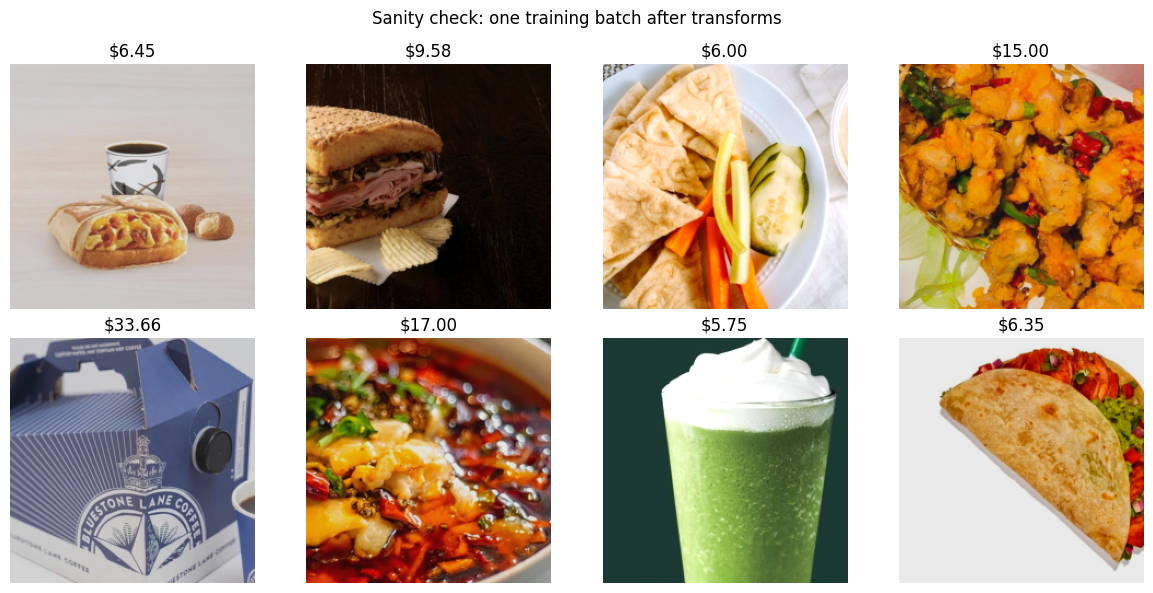

In [10]:
def denormalize(img_tensor: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

images, prices = next(iter(train_loader))
print(f"images batch: {tuple(images.shape)}  dtype={images.dtype}")
print(f"prices batch: {tuple(prices.shape)}  dtype={prices.dtype}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, price in zip(axes.flat, images[:8], prices[:8]):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(f"${price.item():.2f}")
    ax.axis('off')
plt.suptitle('Sanity check: one training batch after transforms')
plt.tight_layout()
plt.show()

In [11]:
class PriceCNN(nn.Module):
    """From-scratch CNN that regresses a single dollar price from a 224x224 RGB image.

    Each `_block` is two 3x3 convolutions with BatchNorm + ReLU followed by a
    2x2 MaxPool. Five blocks take the feature map from 224x224 down to 7x7 while
    growing the channel count 3 -> 32 -> 64 -> 128 -> 256 -> 512, then an
    adaptive average pool collapses the spatial dims so the head is a plain MLP.
    Dropout in the head helps offset the small dataset size.
    """

    def __init__(self, dropout: float = 0.3):
        super().__init__()

        def _block(in_c: int, out_c: int) -> nn.Sequential:
            return nn.Sequential(
                nn.Conv2d(in_c,  out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            _block(3,   32),   # 224 -> 112
            _block(32,  64),   # 112 -> 56
            _block(64,  128),  #  56 -> 28
            _block(128, 256),  #  28 -> 14
            _block(256, 512),  #  14 -> 7
            nn.AdaptiveAvgPool2d(1),  # 7 -> 1
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Output shape: (batch,) so it lines up with our price target tensor.
        return self.head(self.features(x)).squeeze(-1)


def pick_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = pick_device()
print(f"Using device: {device}")

model = PriceCNN(dropout=0.3).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,} total  ({n_trainable:,} trainable)")

with torch.no_grad():
    dummy = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    print(f"Forward-pass shape check: input {tuple(dummy.shape)} -> output {tuple(model(dummy).shape)}")

Using device: mps
Model parameters: 4,780,001 total  (4,780,001 trainable)
Forward-pass shape check: input (2, 3, 224, 224) -> output (2,)


In [12]:
import copy
import time

# Huber loss is robust to the long-tailed dollar distribution: it behaves like
# MSE near zero (smooth gradients) but like MAE in the tails (doesn't let a
# few expensive items dominate the gradient).
criterion = nn.HuberLoss(delta=1.0)

# `optimizer` and `scheduler` are re-created inside the training cell so that
# re-running training always starts with a fresh model + optimizer state.

def run_epoch(loader, train: bool) -> tuple[float, float]:
    """One pass through `loader`. Returns (avg_huber_loss, avg_MAE_in_dollars)."""
    model.train(train)

    total_loss = 0.0
    total_abs_err = 0.0
    total_n = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, prices in loader:
            images = images.to(device, non_blocking=True)
            prices = prices.to(device, non_blocking=True)

            preds = model(images)
            loss = criterion(preds, prices)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_n = prices.size(0)
            total_loss    += loss.item() * batch_n
            total_abs_err += (preds - prices).abs().sum().item()
            total_n       += batch_n

    return total_loss / total_n, total_abs_err / total_n

print('Training helpers ready.')

Training helpers ready.


epoch 01/15  train loss 0.0136 / MAE $ 0.07   val loss 1020204842935667554546142748344320.0000 / MAE $1020204842935667554546142748344320.00   (22.3s)  <- best
epoch 02/15  train loss 0.0008 / MAE $ 0.02   val loss 0.0001 / MAE $ 0.01   (20.6s)  <- best
epoch 03/15  train loss 0.0002 / MAE $ 0.01   val loss 0.0000 / MAE $ 0.01   (20.7s)  <- best
epoch 04/15  train loss 0.0001 / MAE $ 0.01   val loss 0.0000 / MAE $ 0.00   (20.7s)  <- best
epoch 05/15  train loss 0.0001 / MAE $ 0.01   val loss 0.0000 / MAE $ 0.00   (20.8s)  <- best
epoch 06/15  train loss 0.0000 / MAE $ 0.01   val loss 0.0000 / MAE $ 0.00   (21.2s)  <- best
epoch 07/15  train loss 0.0000 / MAE $ 0.01   val loss 0.0000 / MAE $ 0.00   (21.0s)
epoch 08/15  train loss 0.0000 / MAE $ 0.00   val loss 0.0000 / MAE $ 0.00   (20.7s)  <- best
epoch 09/15  train loss 0.0000 / MAE $ 0.00   val loss 0.0000 / MAE $ 0.00   (20.6s)  <- best
epoch 10/15  train loss 0.0000 / MAE $ 0.00   val loss 0.0000 / MAE $ 0.00   (20.7s)  <- best
epoc

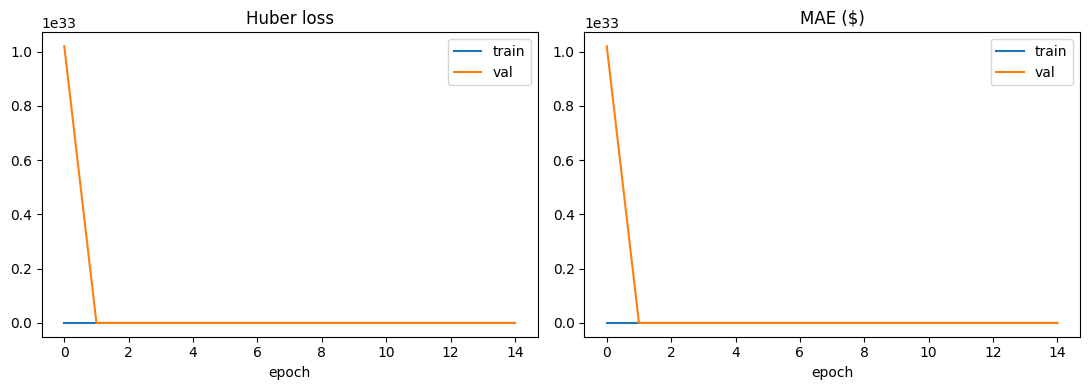

In [13]:
NUM_EPOCHS = 15

# Re-instantiate model + optimizer + scheduler every time this cell runs so
# we never accidentally continue-train from a previous run (which makes
# epoch-1 metrics look impossibly good and the results uninterpretable).
model = PriceCNN(dropout=0.3).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
best_val_mae = float('inf')
best_state: dict | None = None

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_mae = run_epoch(train_loader, train=True)
    va_loss, va_mae = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_mae'].append(tr_mae);   history['val_mae'].append(va_mae)

    improved = va_mae < best_val_mae
    if improved:
        best_val_mae = va_mae
        best_state = copy.deepcopy(model.state_dict())

    dt = time.time() - t0
    flag = '  <- best' if improved else ''
    print(f"epoch {epoch:02d}/{NUM_EPOCHS}  "
          f"train loss {tr_loss:.4f} / MAE ${tr_mae:5.2f}   "
          f"val loss {va_loss:.4f} / MAE ${va_mae:5.2f}   "
          f"({dt:.1f}s){flag}")

if best_state is not None:
    model.load_state_dict(best_state)
print(f"\nRestored best-on-val weights. Best val MAE: ${best_val_mae:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history['train_loss'], label='train'); ax1.plot(history['val_loss'], label='val')
ax1.set_title('Huber loss'); ax1.set_xlabel('epoch'); ax1.legend()
ax2.plot(history['train_mae'], label='train'); ax2.plot(history['val_mae'], label='val')
ax2.set_title('MAE ($)'); ax2.set_xlabel('epoch'); ax2.legend()
plt.tight_layout(); plt.show()

Test Huber loss: 0.0000
Test MAE:        $0.00
Naive baseline (predict $10.52 for everything): MAE $6.12


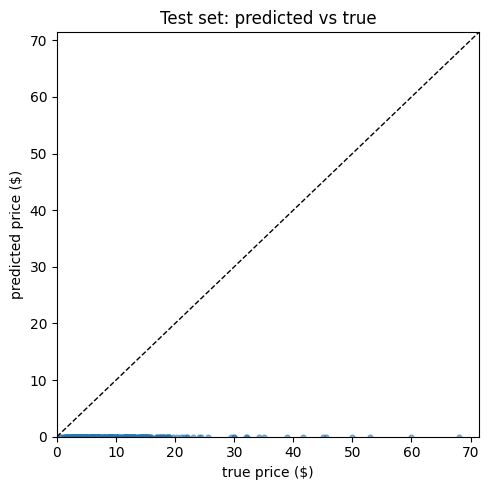

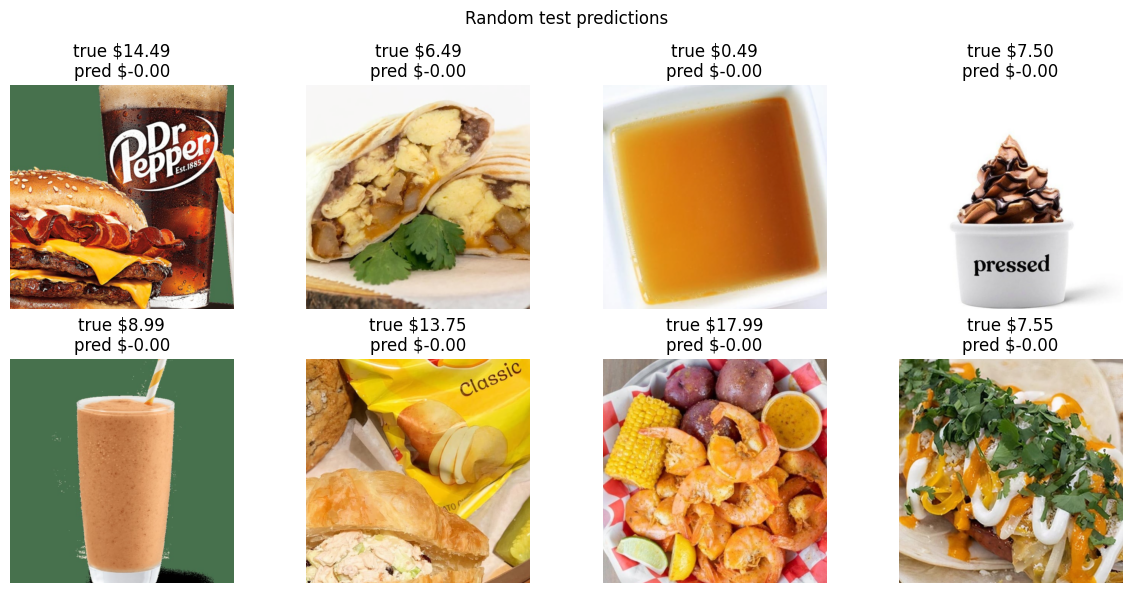

In [14]:
test_loss, test_mae = run_epoch(test_loader, train=False)
print(f"Test Huber loss: {test_loss:.4f}")
print(f"Test MAE:        ${test_mae:.2f}")

# Compare against a trivial baseline: always predict the training set mean.
train_mean = float(train_df[price_col].mean())
naive_mae = (test_df[price_col] - train_mean).abs().mean()
print(f"Naive baseline (predict ${train_mean:.2f} for everything): MAE ${naive_mae:.2f}")

model.eval()
preds_all, truths_all, imgs_all = [], [], []
with torch.no_grad():
    for images, prices in test_loader:
        p = model(images.to(device)).cpu()
        preds_all.append(p); truths_all.append(prices); imgs_all.append(images)
preds  = torch.cat(preds_all).numpy()
truths = torch.cat(truths_all).numpy()
imgs   = torch.cat(imgs_all)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(truths, preds, s=12, alpha=0.5)
lim = max(truths.max(), preds.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('true price ($)'); ax.set_ylabel('predicted price ($)')
ax.set_title('Test set: predicted vs true'); plt.tight_layout(); plt.show()

import numpy as np
idx = np.random.RandomState(0).choice(len(preds), size=8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes.flat, idx):
    ax.imshow(denormalize(imgs[i]).permute(1, 2, 0).numpy())
    ax.set_title(f"true ${truths[i]:.2f}\npred ${preds[i]:.2f}")
    ax.axis('off')
plt.suptitle('Random test predictions'); plt.tight_layout(); plt.show()